# TP 2 - Data Science II

Cette semaine, nous travaillons sur les arbres de décision et la même base de données que la semaine dernière. Mais dès le départ, on fait les choses bien avec la validation croisée.

1. Rendez-vous sur le [challenge Kaggle](https://www.kaggle.com/competitions/challenge-de-classification-cancer-du-sein) et téléchargez 'train.csv' et 'test.csv'.
2. Chargez les 2 datasets et modifiez la colonne 'Diagnosis' en valeurs 0 et 1.

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test.csv')

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test.csv')

train_df['diagnosis'] = train_df['diagnosis'].replace({'M': 1, 'B': 0})

test_ids = test_df['Unnamed: 0']
train_df = train_df.drop(['id', 'ID', 'Unnamed: 0'], axis=1, errors='ignore')
test_df = test_df.drop(['id', 'ID', 'Unnamed: 0'], axis=1, errors='ignore')

y = train_df['diagnosis']
X = train_df.drop('diagnosis', axis=1)

/tmp/ipython-input-114924779.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['diagnosis'] = train_df['diagnosis'].replace({'M': 1, 'B': 0})


3. Trouvez dans `scikit-learn` l'objet qui vous permettra d'entrainer un arbre de décision pour la classification binaire. En validation croisée, optimisez la profondeur (`max_depth`) de cet arbre, en gardant les autres paramètres par défaut.

In [ ]:
for depth in range(1, 21):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    score = cross_val_score(dt, X, y, cv=5).mean()
    print(f"max_depth={depth}: {score:.4f}")

max_depth=1: 0.9146
max_depth=2: 0.9122
max_depth=3: 0.9247
max_depth=4: 0.9272
max_depth=5: 0.9247
max_depth=6: 0.9121
max_depth=7: 0.9096
max_depth=8: 0.9096
max_depth=9: 0.9096
max_depth=10: 0.9096
max_depth=11: 0.9096
max_depth=12: 0.9096
max_depth=13: 0.9096
max_depth=14: 0.9096
max_depth=15: 0.9096
max_depth=16: 0.9096
max_depth=17: 0.9096
max_depth=18: 0.9096
max_depth=19: 0.9096
max_depth=20: 0.9096


4. Produisez un graphe qui montre l'accuracy moyenne en validation croisée en fonction de la valeur de ce paramètre. Pour afficher également la variablité entre les folds, vous pouvez utiliser `matplotlib.pyplot.errorbar`.

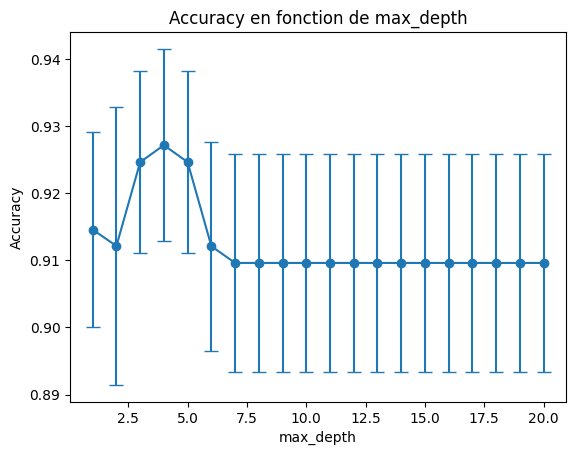

In [ ]:
import matplotlib.pyplot as plt

depths = range(1, 21)
scores_mean = []
scores_std = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X, y, cv=5)
    scores_mean.append(scores.mean())
    scores_std.append(scores.std())

plt.errorbar(depths, scores_mean, yerr=scores_std, marker='o', capsize=5)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction de max_depth')
plt.show()

Meilleur score à max_depth=4 (0.927). Au-delà, l'accuracy diminue et se stabilise autour de 0.91, il y a surapprentissage .

5. En utilisant la meilleure des valeurs, entrainez un arbre sur tout l'ensemble, prédisez les valeurs sur Xtest et soumettez sur Kaggle. Faites-vous mieux ou moins bien qu'avec les KNN ?

In [ ]:
dt_final = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_final.fit(X, y)

predictions = dt_final.predict(test_df)
predictions_labels = ['M' if p == 1 else 'B' for p in predictions]

submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_dt.csv', index=False)

Avec KNN on a ~0.97, et l'arbre de décision donne ~0.93 en validation croisée. KNN fait mieux sur ce dataset

6. Essayez maintenant d'optimiser non pas un seul mais deux paramètres à la fois: `max_depth` et `criterion`.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': range(1, 21), 'criterion': ['gini', 'entropy']}
dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, param_grid, cv=5)
grid.fit(X, y)

print(f"Meilleurs paramètres: {grid.best_params_}")
print(f"Meilleur score: {grid.best_score_:.4f}")

Meilleurs paramètres: {'criterion': 'entropy', 'max_depth': 3}
Meilleur score: 0.9397


7. Vous avez maintenant les clés pour optimiser encore plus de paramètres et faire mieux sur Kaggle. Pourquoi ne pas même essayer de combiner avec les KNN ? Tout est possible... Qui fera le meilleur score ?

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 15),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, param_grid, cv=5)
grid.fit(X, y)

print(f"Meilleurs paramètres: {grid.best_params_}")
print(f"Meilleur score: {grid.best_score_:.4f}")

Meilleurs paramètres: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur score: 0.9397


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
dt = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

voting = VotingClassifier(estimators=[('knn', knn), ('dt', dt)], voting='hard')
voting.fit(X_scaled, y)

test_scaled = scaler.transform(test_df)
predictions = voting.predict(test_scaled)
predictions_labels = ['M' if p == 1 else 'B' for p in predictions]

submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_voting.csv', index=False)

On obtient un score de : 0,96774

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X, y)

predictions = rf.predict(test_df)
predictions_labels = ['M' if p == 1 else 'B' for p in predictions]

submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_rftp2.csv', index=False)

On trouve : 0,97849

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
knn.fit(X_scaled, y)

predictions = knn.predict(test_scaled)
predictions_labels = ['M' if p == 1 else 'B' for p in predictions]

submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_knn_opt.csv', index=False)

On trouve un score de 0,98924. Le KNN avec metric='manhattan'et weights='distance'fonctionne très bien sur ce dataset.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in [1, 2, 3, 4, 5, 6, 7]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    score = cross_val_score(knn, X_scaled, y, cv=5).mean()
    print(f"k={k}: {score:.4f}")

k=1: 0.9498
k=2: 0.9498
k=3: 0.9598
k=4: 0.9598
k=5: 0.9547
k=6: 0.9572
k=7: 0.9547


In [ ]:
for metric in ['manhattan', 'euclidean', 'chebyshev', 'minkowski']:
    knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric=metric)
    score = cross_val_score(knn, X_scaled, y, cv=5).mean()
    print(f"{metric}: {score:.4f}")

manhattan: 0.9598
euclidean: 0.9598
chebyshev: 0.9446
minkowski: 0.9598


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

# 3 meilleurs modèles
knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
knn.fit(X_scaled, y)
pred_knn = knn.predict(test_scaled)

svm = SVC(kernel='rbf', C=10, gamma=0.01)
svm.fit(X_scaled, y)
pred_svm = svm.predict(test_scaled)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_scaled, y)
pred_rf = rf.predict(test_scaled)

# Voir où ils ne sont pas d'accord
for i in range(len(pred_knn)):
    if not (pred_knn[i] == pred_svm[i] == pred_rf[i]):
        print(f"Index {i}: KNN={pred_knn[i]}, SVM={pred_svm[i]}, RF={pred_rf[i]}")

Index 8: KNN=1, SVM=0, RF=1
Index 52: KNN=1, SVM=0, RF=0
Index 82: KNN=1, SVM=1, RF=0
Index 164: KNN=0, SVM=1, RF=0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
knn.fit(X_scaled, y)

probas = knn.predict_proba(test_scaled)
predictions = knn.predict(test_scaled)

# Afficher les cas où KNN est le moins sûr (proche de 0.5)
for i in range(len(probas)):
    confidence = max(probas[i])
    if confidence < 0.75:
        print(f"Index {i}: pred={predictions[i]}, proba={probas[i]}, confidence={confidence:.3f}")

Index 8: pred=1, proba=[0.27819815 0.72180185], confidence=0.722
Index 13: pred=1, proba=[0.32247768 0.67752232], confidence=0.678
Index 20: pred=0, proba=[0.67512163 0.32487837], confidence=0.675
Index 44: pred=0, proba=[0.65694614 0.34305386], confidence=0.657
Index 45: pred=0, proba=[0.66137274 0.33862726], confidence=0.661
Index 52: pred=1, proba=[0.3301932 0.6698068], confidence=0.670
Index 58: pred=1, proba=[0.3175859 0.6824141], confidence=0.682
Index 65: pred=0, proba=[0.65080411 0.34919589], confidence=0.651
Index 70: pred=1, proba=[0.33881519 0.66118481], confidence=0.661
Index 84: pred=1, proba=[0.27410393 0.72589607], confidence=0.726
Index 91: pred=0, proba=[0.62727348 0.37272652], confidence=0.627
Index 100: pred=1, proba=[0.29862756 0.70137244], confidence=0.701
Index 109: pred=0, proba=[0.66113063 0.33886937], confidence=0.661
Index 136: pred=0, proba=[0.6840509 0.3159491], confidence=0.684


14 cas incertains. Les 2 erreurs sont probablement parmi ceux-là. Index 91 (0.627) et 65 (0.651) sont les moins sûrs.

In [ ]:
#A TESTER
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
knn.fit(X_scaled, y)
predictions = knn.predict(test_scaled).copy()

# Inverser index 91 (le moins sûr: 0.627)
predictions[91] = 1  # était 0

predictions_labels = ['M' if p == 1 else 'B' for p in predictions]
submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_test91.csv', index=False)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
knn.fit(X_scaled, y)
predictions = knn.predict(test_scaled).copy()

# Cas à tester un par un :
# predictions[91] = 1
# predictions[65] = 1
# predictions[44] = 1
# predictions[45] = 1
# predictions[20] = 1

predictions_labels = ['M' if p == 1 else 'B' for p in predictions]
submission = pd.DataFrame({'ID': test_ids, 'label': predictions_labels})
submission.to_csv('submission_test.csv', index=False)#A TESTER